# Econ 470 HW 4.1
## Claire Hamilton

In [1]:
# Import packages

library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# Read data

years <- 2009:2019

final_data <- map_dfr(
  years,
  ~ read_csv(paste0("../data/output/data-", .x, ".csv"), show_col_types = FALSE)
)

In [11]:
final.hcris.v1996=read_csv('../data/output/HCRIS_Data_v1996.csv', show_col_types = FALSE)
final.hcris.v2010=read_csv('../data/output/HCRIS_Data_v2010.csv', show_col_types = FALSE)

## create missing variables for columns introduced in v2010 of hcris forms
final.hcris.v1996 = final.hcris.v1996 %>%
  mutate(hvbp_payment=NA, hrrp_payment=NA)

## combine v1996 and v2010 hcris forms, and sort by provider_number/year
final.hcris <- bind_rows(final.hcris.v1996, final.hcris.v2010) %>%
  mutate(
    fy_end = mdy(fy_end),
    fy_start = mdy(fy_start),
    date_processed = mdy(date_processed),
    date_created = mdy(date_created),
    tot_discounts = abs(tot_discounts),
    hrrp_payment = abs(hrrp_payment)
  ) %>%
  mutate(fyear = year(fy_end)) %>%
  arrange(provider_number, fyear) %>%
  select(-any_of("year"))

In [12]:
# glimpse(final.hcris)

## Question 1

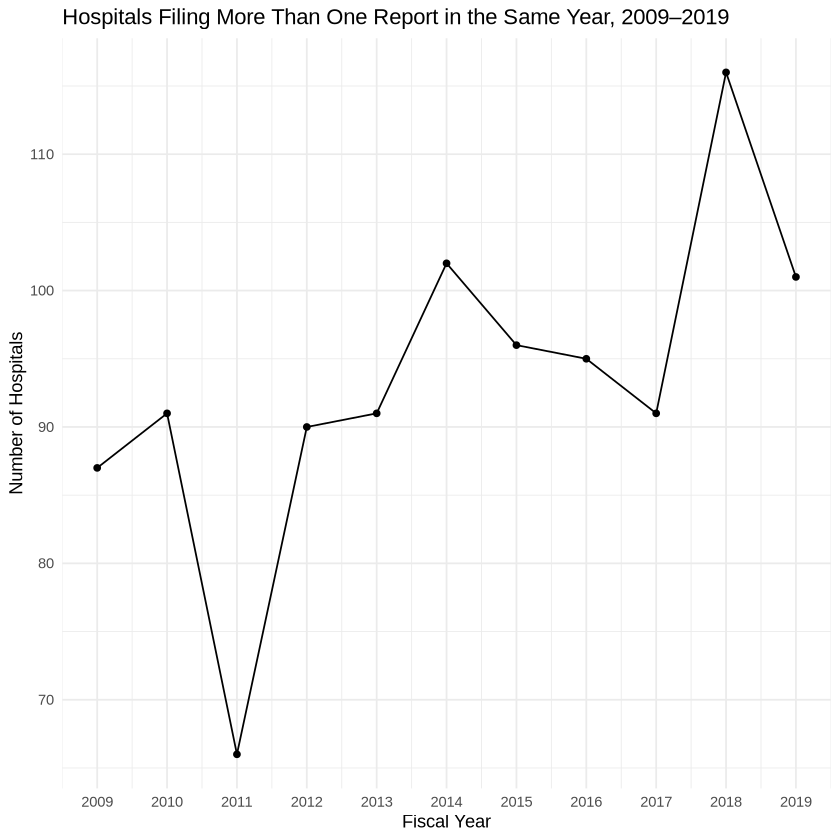

In [5]:
# Question 1

hospitals_per_year <- final.hcris %>%
  filter(fyear >= 2009, fyear <= 2019) %>%
  group_by(fyear, provider_number) %>%
  summarize(n_reports = n(), .groups = "drop") %>%
  filter(n_reports > 1) %>%
  count(fyear, name = "n_hospitals") %>%
  complete(fyear = 2009:2019, fill = list(n_hospitals = 0))

ggplot(hospitals_per_year, aes(x = fyear, y = n_hospitals)) +
  geom_line() +
  geom_point() +
  scale_x_continuous(breaks = 2009:2019) +
  labs(
    title = "Hospitals Filing More Than One Report in the Same Year, 2009–2019",
    x = "Fiscal Year",
    y = "Number of Hospitals"
  ) +
  theme_minimal()

## Question 2

In [6]:
# Question 2

n_hospitals <- final_data %>%
  summarize(n = n_distinct(provider_number))

n_hospitals

n
<int>
6893


## Question 3

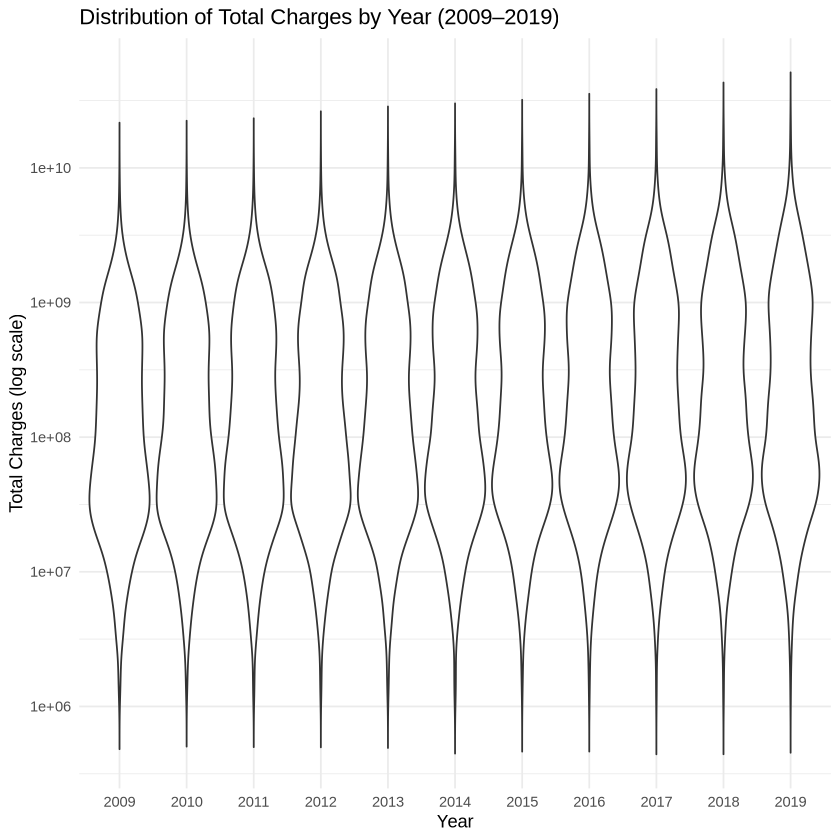

In [7]:
# Question 3

final_data %>%
  filter(
    year >= 2009, year <= 2019,
    !is.na(tot_charges),
    tot_charges > 1e6   # filter out unrealistic values (< $1M)
  ) %>%
  ggplot(aes(x = factor(year), y = tot_charges)) +
  geom_violin(trim = FALSE) +
  scale_y_log10() +
  labs(
    title = "Distribution of Total Charges by Year (2009–2019)",
    x = "Year",
    y = "Total Charges (log scale)"
  ) +
  theme_minimal()

## Question 4

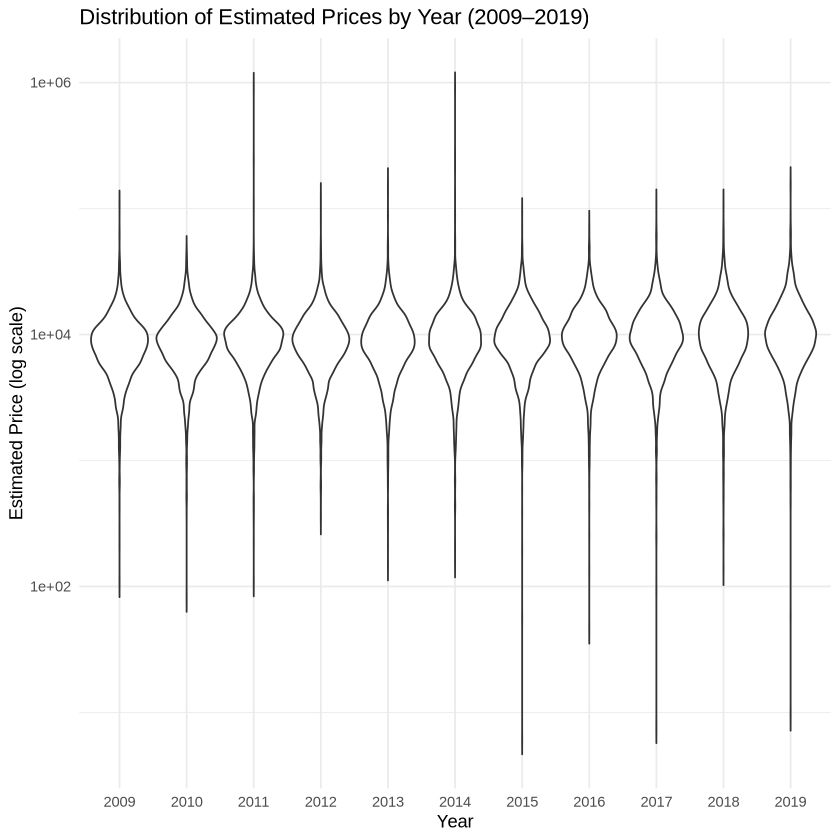

In [8]:
# Question 4

final_data %>%
  mutate(
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(
    year >= 2009, year <= 2019,
    !is.na(price),
    price > 0,               
    price_denom > 0,           
    price < 1e6           
  ) %>%
  ggplot(aes(x = factor(year), y = price)) +
  geom_violin(trim = FALSE) +
  scale_y_log10() +
  labs(
    title = "Distribution of Estimated Prices by Year (2009–2019)",
    x = "Year",
    y = "Estimated Price (log scale)"
  ) +
  theme_minimal()

## Question 5

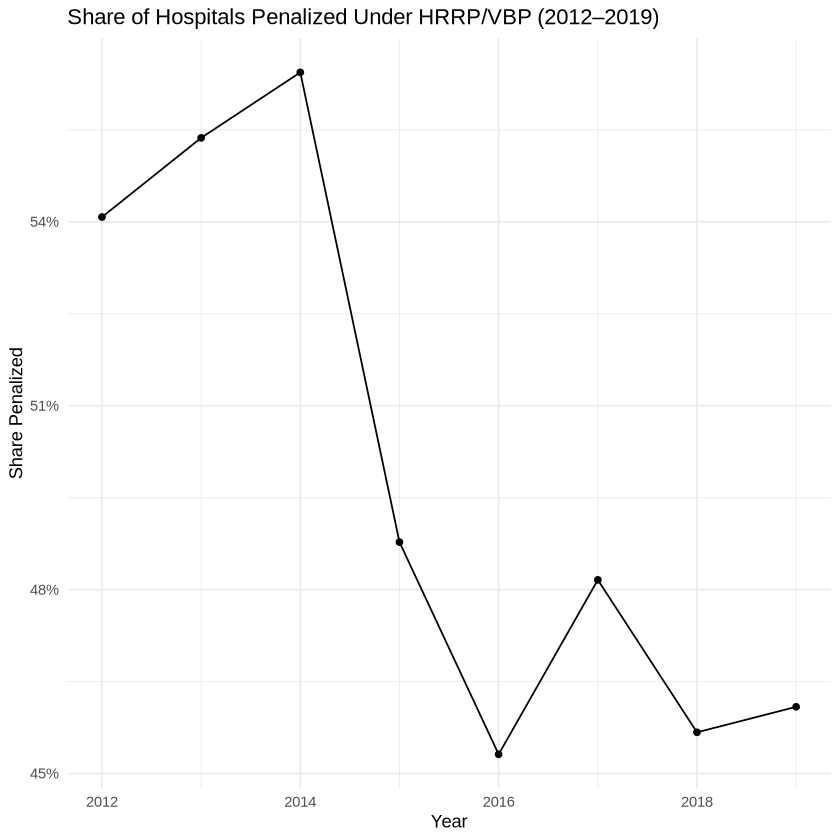

In [9]:
# Question 5

penalty_share <- final_data %>%
  filter(year >= 2012, year <= 2019) %>%
  mutate(
    penalized = if_else(hrrp_payment < 0 | hvbp_payment < 0, 1, 0)
  ) %>%
  group_by(year) %>%
  summarize(
    share_penalized = mean(penalized, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(penalty_share, aes(x = year, y = share_penalized)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = "Share of Hospitals Penalized Under HRRP/VBP (2012–2019)",
    x = "Year",
    y = "Share Penalized"
  ) +
  theme_minimal()